# **Логистическая регрессия. Классификация**

In [ ]:
import pandas as pd
import numpy as np

Регрессионные модели

reg1.png

## **A3**

Аналитик Арсений специализируется в применениях методов машинного обучения и статистики для областей сельского хозяйства. Он решает задачу классификации типа почвы и хочет построить модель для разделения чернозёма и прочих типов. Для этого он использует данные по содержанию гуминовых кислот в кДа (acidG) и фульвокислот в кДа (acidF) в образцах почвы. Он оценил логистическую регрессию на обучающей выборке.

Оказалось, что уравнение оценённой модели выглядит следующим образом:

$$𝑃̂ (y=Chernozem)=𝜎(0.00−0.01×acidG_i+0.2×acidF_i)$$

где 𝑦 – значение целевой переменной для наблюдения 𝑖

acidG𝑖 и acidF𝑖 – значения признаков для наблюдения 𝑖

𝜎(⋅) – логистическая функция.

Пусть имеется образец почвы с содержанием гуминовых кислот 15 кДа и фульвокислот 4 кДа. Найдите оценку вероятности принадлежности этого образца к чернозёму, которую выдаст модель Арсения. Ответ округлите до сотых.




Выберите один ответ:

- 0.52


- 0.54


- 0.66


- 0.71

$$\Huge \sigma(X) = \frac{1}{1+e^{-X}}$$

In [ ]:
import numpy as np

round(1/(1+np.exp(-(-0.01*15+0.2*4))), 2)

0.66

## Данные

preg = количество беременностей

plas = концентрация глюкозы в плазме

pres = артериальное давление (mm Hg)

skin = толщина кожной складки трицепса (mm)

test = инсулин (mu U/ml)

mass = индекс массы тела (weight in kg/(height in m)^2)

pedi = вероятность унаследовать диабет

age = возраст

class = диабет (1:есть, 0: нет)

In [ ]:
df1 = pd.read_csv('https://raw.githubusercontent.com/prvshnat/hsedata2425/refs/heads/main/pima-indians-diabetes.csv',
                  names = ['preg', 'plas', 'pres', 'skin',
                           'test', 'mass', 'pedi', 'age', 'class'])
df1.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<Axes: xlabel='class'>

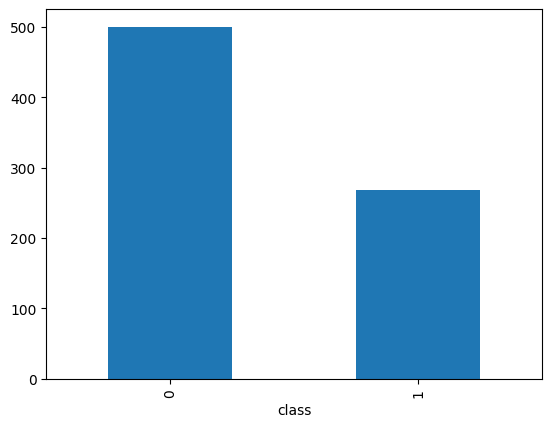

In [ ]:
df1['class'].value_counts().plot(kind='bar')

### Разделяем выборку

In [ ]:
from sklearn.model_selection import train_test_split

X = df1[['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']]
y = df1['class']
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)

## Логистическая регрессия

В задаче *Логистической регрессии* мы предсказываем **вероятность** (количественная величин) принадлежности объекта к классу

### **Модель 1**



$$ P(class = 1) = \sigma(w_0 + w_1*\text{mass} + w_2*\text{pedi}) $$

#### Обучение

**Метод максимального правдоподобия**

Наши y могут принимать значения $1$ и $0.$ Если $y = 1$, мы хотим, чтобы модель спрогнозировала $p(x) = P(y = 1 \mid x)$ побольше. Если $y = 0$, мы хотим, чтобы модель спрогнозировала $p(x)$ поменьше, то есть $1 − p(x)$ побольше.

Тогда мы можем выписать такую штуку:

$$
-\frac{1}{n} \sum_{i=1}^n \cdot [ y_i \cdot p(x_i)  + (1 - y_i) \cdot (1 - p(x_i))  ] \to \min
$$

Нам надо найти её минимум по весам модели. Если $y = 1$, мы будем получать большое $p(x)$, так ка второе слагаемое в нашей формуле будет зануляться. Если $y = 0$, то будет зануляться первое слагаемое, и мы будем пытаться получить большое $1 − p(x)$.

In [ ]:
from sklearn.linear_model import LogisticRegression
X_train1 = X_train[['mass', 'pedi']]
model1 = LogisticRegression().fit(X_train1, y_train)

Коэффициенты полученной модели:

In [ ]:
model1.coef_.round(2) #коэффициенты перед независимой переменной

array([[0.09, 0.72]])

In [ ]:
model1.intercept_.round(2) #свободные коэффициенты

array([-4.08])

$$ P(class = 1) = \sigma(-4.08 + 0.09*\text{mass} + 0.72*\text{pedi}) $$

#### Тестирование

##### Logg-loss

$$
logloss = -\frac{1}{n} \sum_{i=1}^n \cdot [y_i  \cdot \ln p(x_i) + (1 - y_i) \cdot \ln (1 - p(x_i))]
$$

In [ ]:
from sklearn.metrics import log_loss
X_test1 = X_test[['mass', 'pedi']]
y_pred_proba1 = model1.predict_proba(X_test1) #вероятноть диабета/не диабета для Модели 1
log_loss(y_test, y_pred_proba1)

0.6033591471376785

In [ ]:
X_test1

,mass,pedi
668,34.0,0.430
324,35.7,0.148
624,30.8,0.158
690,24.6,0.856
473,29.9,0.210
...,...,...
355,30.4,0.302
534,33.3,1.251
344,36.8,0.485
296,28.0,0.337


In [ ]:
y_pred_proba1

array([[0.63277318, 0.36722682],
       [0.64211769, 0.35788231],
       [0.73928215, 0.26071785],
       [0.75604953, 0.24395047],
       [0.74846155, 0.25153845],
       [0.56683709, 0.43316291],
       [0.87110828, 0.12889172],
       [0.55083573, 0.44916427],
       [0.70392608, 0.29607392],
       [0.67353663, 0.32646337],
       [0.79696725, 0.20303275],
       [0.67159702, 0.32840298],
       [0.73855597, 0.26144403],
       [0.54401801, 0.45598199],
       [0.69741895, 0.30258105],
       [0.55725319, 0.44274681],
       [0.58835246, 0.41164754],
       [0.7214803 , 0.2785197 ],
       [0.77404377, 0.22595623],
       [0.432318  , 0.567682  ],
       [0.77478709, 0.22521291],
       [0.68575525, 0.31424475],
       [0.61721256, 0.38278744],
       [0.67279921, 0.32720079],
       [0.61566338, 0.38433662],
       [0.61194198, 0.38805802],
       [0.82608212, 0.17391788],
       [0.8928916 , 0.1071084 ],
       [0.41822498, 0.58177502],
       [0.68978012, 0.31021988],
       [0.

Чем меньше, тем лучше

### **Модель 2**

$$ P(class = 1) = \sigma(w_0+w_1*\text{preg}+w_2*\text{plas}+w_3*\text{pres} + w_4*\text{skin} + w_5*\text{test} + w_6*\text{mass} + w_7*\text{pedi} + w_8*\text{age}) $$

#### Обучение

In [ ]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression().fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Коэффициенты полученной модели:

In [ ]:
model2.coef_.round(2) #коэффициенты перед независимой переменной

array([[ 0.06,  0.03, -0.01,  0.  , -0.  ,  0.1 ,  0.59,  0.04]])

In [ ]:
model2.intercept_.round(2) #свободные коэффициенты

array([-8.91])

$$ P(class = 1) = \sigma(-8.91+0.06*\text{preg}+0.03*\text{plas}-0.01*\text{pres} + 0*\text{skin} + 0*\text{test} + 0.1*\text{mass} + 0.59*\text{pedi} + 0.04*\text{age}) $$

#### Тестирование

In [ ]:
from sklearn.metrics import log_loss
y_pred_proba2 = model2.predict_proba(X_test) #вероятноть диабета/не диабета для Модели 2
log_loss(y_test, y_pred_proba2)

0.5099870141616671

## Классификация

В задаче *Классификации* мы предсказываем **класс объекта** (категориальный признак)

### Обучение

НА ОБУЧАЮЩЕЙ ВЫБОРКЕ

Не отличается от логистической регрессии

### Тестирование

Делаем предсказание **класса**

In [ ]:
y_pred1 = model1.predict(X_test1) #вероятноть диабета/не диабета для Модели 1
y_pred2 = model2.predict(X_test) #вероятноть диабета/не диабета для Модели 1
y_pred2

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

#### Матрица ошибок

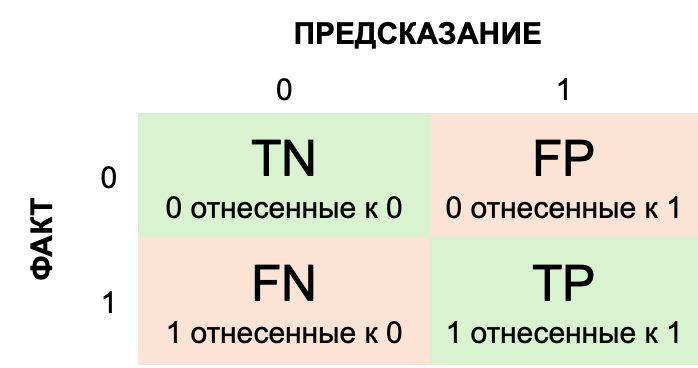

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred1) #Модель 1

array([[90,  9],
       [38, 17]])

In [ ]:
confusion_matrix(y_test, y_pred2) #Модель 2

array([[78, 21],
       [18, 37]])

**Accuracy** - Доля правильно определенных объектов

$$\Huge Accuracy = \frac{TN+TP}{TN+TP+FP+FN} $$

In [ ]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test, y_pred1)
accuracy2 = accuracy_score(y_test, y_pred2)
accuracy1, accuracy2

(0.6948051948051948, 0.7467532467532467)

**Precision** - доля правильно определенных объектов, отнесененных к положительному классу

$$\Huge Precion = \frac{TP}{TP+FP} $$

In [ ]:
from sklearn.metrics import precision_score

precision1 = precision_score(y_test, y_pred1)
precision2 = precision_score(y_test, y_pred2)
precision1, precision2

(0.6538461538461539, 0.6379310344827587)

**Recall** - доля правильно определенных положительных объектов, среди всех положительных объектов

$$\Huge Recall = \frac{TP}{TP+FN} $$

In [ ]:
from sklearn.metrics import recall_score

recall1 = recall_score(y_test, y_pred1)
recall2 = recall_score(y_test, y_pred2)
recall1, recall2

(0.3090909090909091, 0.6727272727272727)

**F1** - среднее гармоничеческое precision и recall

$$\Huge F1 = \frac{2}{\frac{1}{Recall}+\frac{1}{Precision}}$$

In [ ]:
from sklearn.metrics import f1_score

f1score1 = f1_score(y_test, y_pred1)
f1score2 = f1_score(y_test, y_pred2)
f1score1, f1score2

(0.41975308641975306, 0.6548672566371682)

In [ ]:
from sklearn.metrics import classification_report
print('Модель 1')
print(classification_report(y_test, y_pred1))

Модель 1
              precision    recall  f1-score   support

           0       0.70      0.91      0.79        99
           1       0.65      0.31      0.42        55

    accuracy                           0.69       154
   macro avg       0.68      0.61      0.61       154
weighted avg       0.69      0.69      0.66       154



In [ ]:
print('Модель 2')
print(classification_report(y_test, y_pred2))

Модель 2
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



#### ROC-AUC

**ROC кривая** - отображает зависимость между **TPR** (Recall) и **FPR**

$$ TPR = \frac{TP}{TP+FN} $$

$$ FPR = \frac{FP}{FP+TN} $$

**AUC** - площадь под ROC кривой

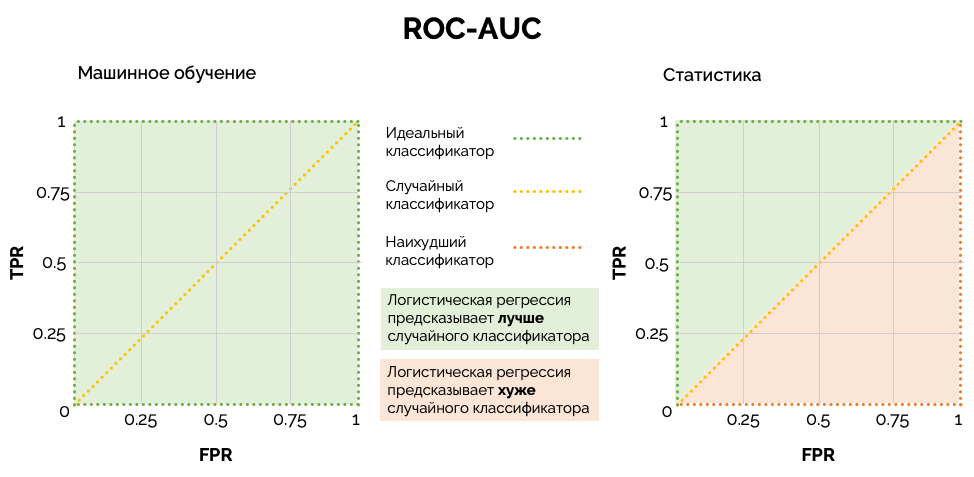

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
roc_auc1 = roc_auc_score(y_test, y_pred_proba1[:, 1])
roc_auc2 = roc_auc_score(y_test, y_pred_proba2[:, 1])
roc_auc1, roc_auc2

(0.686317722681359, 0.8128558310376492)

In [ ]:
y_pred_proba1[:, 1] #вероятность попадания в класс 1

array([0.36722682, 0.35788231, 0.26071785, 0.24395047, 0.25153845,
       0.43316291, 0.12889172, 0.44916427, 0.29607392, 0.32646337,
       0.20303275, 0.32840298, 0.26144403, 0.45598199, 0.30258105,
       0.44274681, 0.41164754, 0.2785197 , 0.22595623, 0.567682  ,
       0.22521291, 0.31424475, 0.38278744, 0.32720079, 0.38433662,
       0.38805802, 0.17391788, 0.1071084 , 0.58177502, 0.31021988,
       0.81943804, 0.48678344, 0.40654255, 0.39822651, 0.64060727,
       0.45165208, 0.40757074, 0.40553767, 0.20134505, 0.55333674,
       0.22776565, 0.2586862 , 0.43255407, 0.31330495, 0.11356988,
       0.38445512, 0.60744473, 0.44125841, 0.22488048, 0.76188965,
       0.16409707, 0.34271417, 0.50481165, 0.27932294, 0.1379411 ,
       0.25921925, 0.24935487, 0.01884357, 0.56606678, 0.29744788,
       0.33478674, 0.41510758, 0.1416767 , 0.31077756, 0.42883282,
       0.56250096, 0.22410524, 0.67142465, 0.12839016, 0.60998781,
       0.432481  , 0.25524919, 0.16269755, 0.41277843, 0.16885

<ipython-input-27-b15fafddf010>:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--',


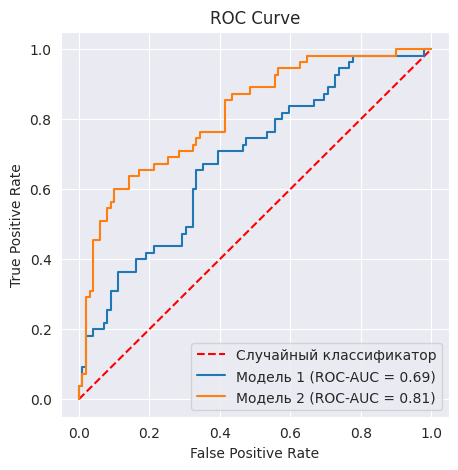

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

fig, ax = plt.subplots(1, 1, figsize = (5, 5))

fpr1, tpr1, thresholds1 = roc_curve(y_test, y_pred_proba1[:, 1], pos_label=1) #Модель 1 для класса с диабетом
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_pred_proba2[:, 1], pos_label=1) #Модель 2 для класса с диабетом

d = {1: [(fpr1, tpr1), roc_auc1, 'b'],
     2: [(fpr2, tpr2), roc_auc2, 'g']}

plt.plot([0, 1], [0, 1], 'k--',
         label='Cлучайный классификатор',
         color = 'r', )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

for k,v in d.items():
  plt.plot(v[0][0], v[0][1],
           label=f'Модель {k} (ROC-AUC = %0.2f)' % v[1])
plt.legend(loc="lower right")

## **A15**

На рисунке изображена ROC-кривая для некоторой логистической регрессии, построенная для тестовой выборки. Выберите все верные утверждения о качестве предсказаний этой регрессии.

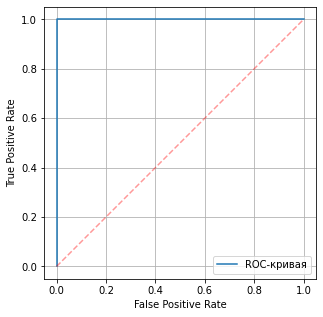

Выберите один или несколько ответов:

- В соответствии с ROC-кривой, если FPR равна 0.2, то TPR также равна 0.2.


- Изображённая ROC-кривая совпадает с кривой идеального классификатора.


- В среднем логистическая регрессия предсказывает лучше, чем случайный классификатор.


- Изображённая ROC-кривая совпадает с кривой наихудшего классификатора.

На рисунке изображена ROC-кривая для некоторой логистической регрессии, построенная для тестовой выборки. Для определения наихудшего классификатора используется подход из машинного обучения. Выберите верное утверждение о качестве предсказаний этой регрессии.

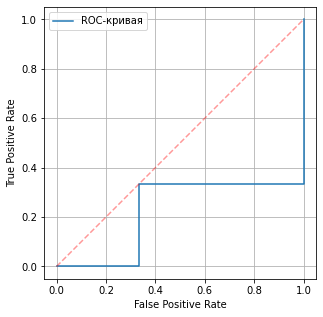


- В среднем логистическая регрессия предсказывает лучше, чем случайный классификатор.


- В среднем логистическая регрессия предсказывает хуже, чем случайный классификатор.


- Изображённая ROC-кривая совпадает с кривой наихудшего классификатора.


- Изображённая ROC-кривая совпадает с кривой наилучшего классификатора.

## Многоклассовая классификация

Даннные по растениям:

**sepal length** - длина наружной доли околоцветника

**sepal width** - ширина наружной доли околоцветника

**petal length** - длина внутренней доли околоцветника

**petal width** - ширина внутренней доли околоцветника

**type** - класс ириса: setosa (0), versicolor (1) или virginica (2)

<img src="https://ranalytics.github.io/data-mining/figures/iris.PNG">

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()
df2 =  pd.DataFrame(data['data'], columns = data['feature_names'])
df2['type'] = data['target']
df2.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Разделяем выборку

In [ ]:
from sklearn.model_selection import train_test_split

X = df2[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df2['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

### Обучение и тестирование

In [ ]:
X.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

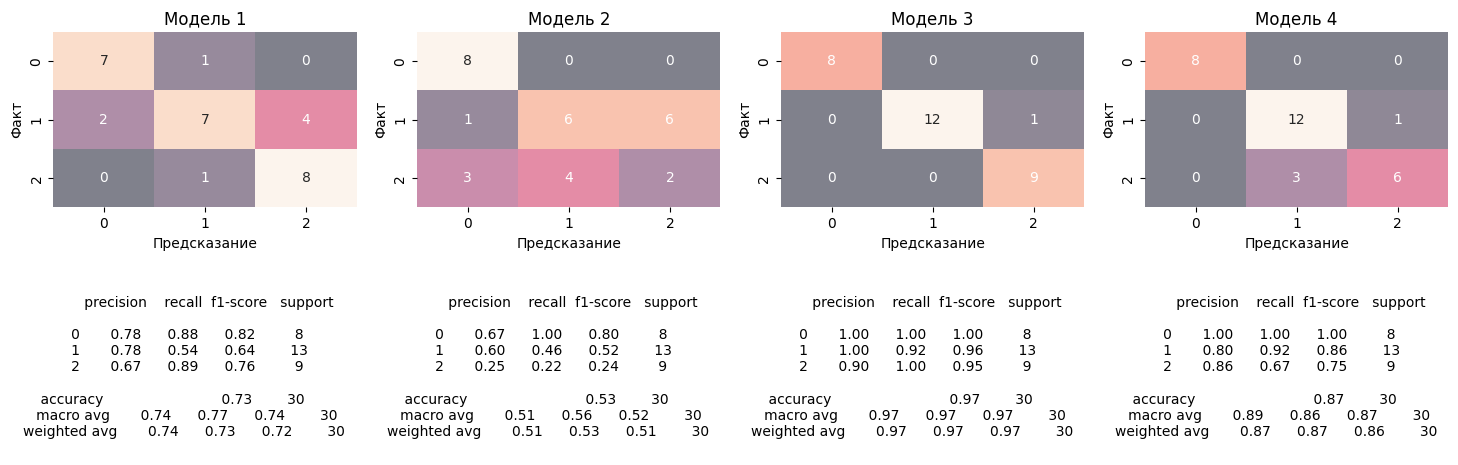

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

fig, ax = plt.subplots(2, 4, figsize=(18, 5))
lst = []

for col in X.columns:
  # Обучение
  model = LogisticRegression()
  #lst.append(col)
  x_train = np.array(X_train[col]).reshape(-1,1)
  model.fit(x_train, y_train)

  # Тестирование
  x_test = np.array(X_test[col]).reshape(-1,1)
  y_pred = model.predict(x_test) #предсказываем класс


  pos2 = len(lst)-1 #позиция на графике
  ax[0][pos2].set_title(f'Модель {len(lst)}')

  ##добавляем матрицу ошибок
  cm = confusion_matrix(y_test, y_pred)#матрица ошибок
  sns.heatmap(cm,
              ax = ax[0][pos2],
              annot = True,
              cbar=False,
              alpha=0.5)
  ax[0][pos2].set_xlabel(f'Предсказание')
  ax[0][pos2].set_ylabel(f'Факт')

  ##добавляем метрики
  metrix = classification_report(y_test, y_pred)
  ax[1][pos2].text(-0.1, -0.2, metrix)
  ax[1][pos2].axis('off');

Матрица Ошибок:

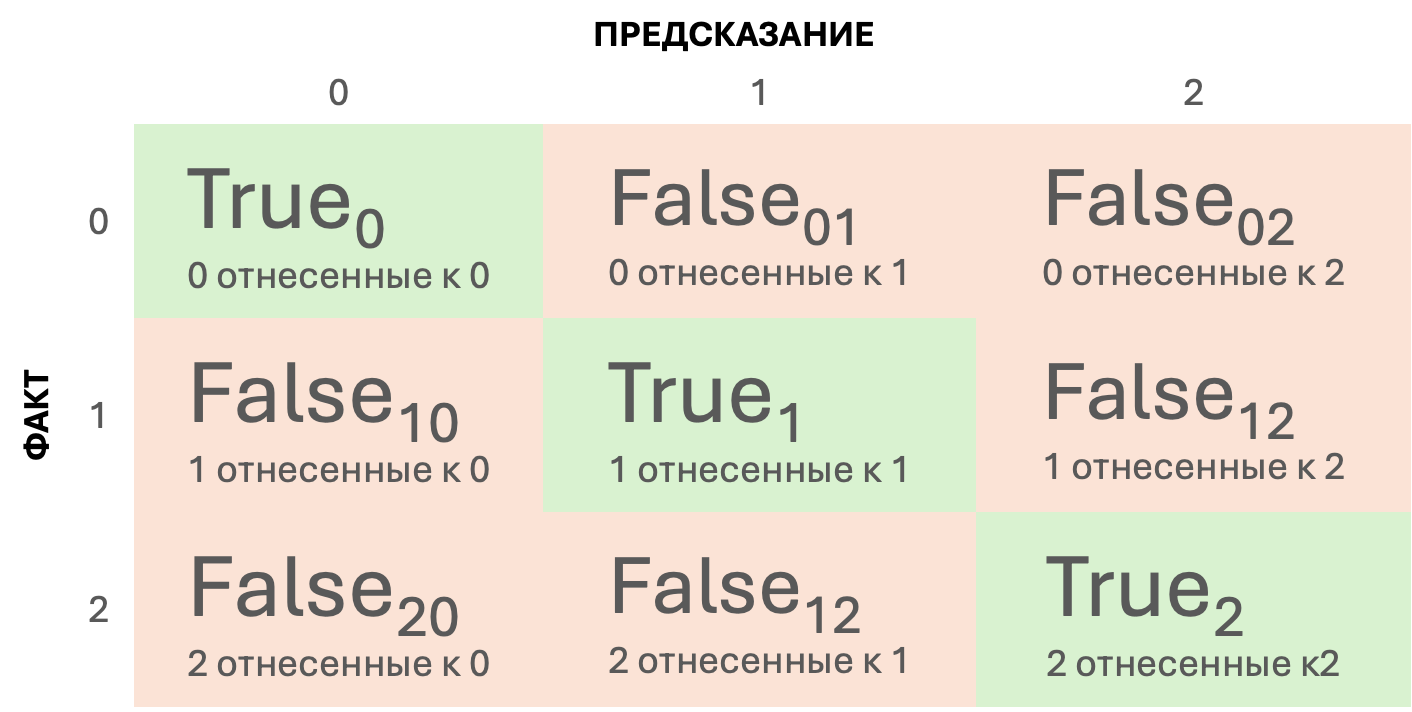

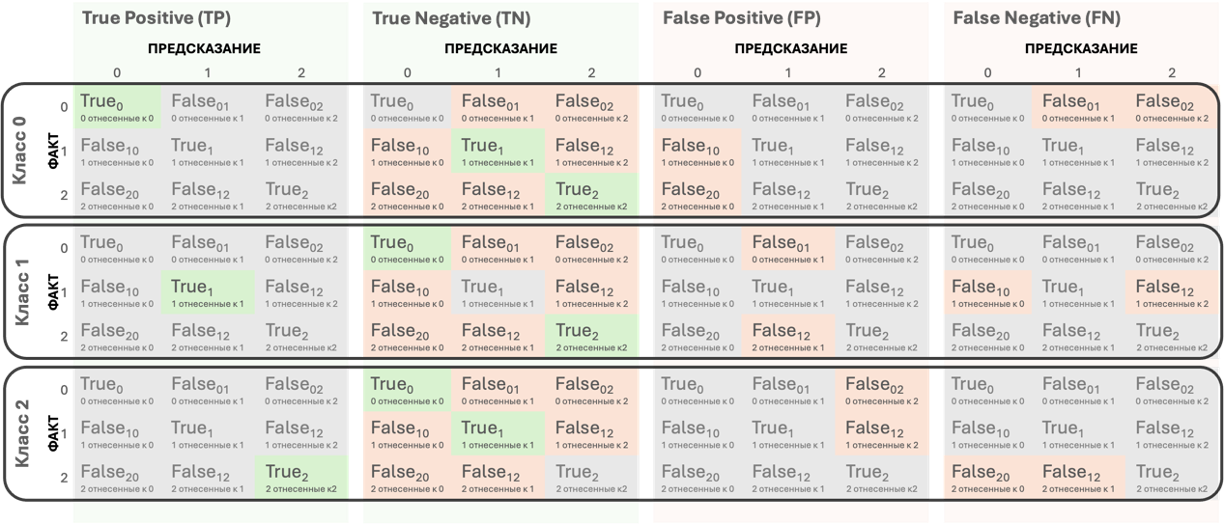